<h1 align='center' style='color:#2e7d32; font-size:2.5em'>📊 Curso de Estatística — Parte 2</h1>
<h3 align='center' style='color:#555'>Distribuições de Probabilidade · Amostragem · Estimação · Intervalos de Confiança</h3>

---

> **Dataset:** Pesquisa Nacional por Amostra de Domicílios (PNAD) 2015 — IBGE  
> **Variáveis:** Renda, Idade, Altura, UF, Sexo, Anos de Estudo, Cor  
> **Fonte:** https://ww2.ibge.gov.br

## 🔧 0. Setup — Instalação e Importações

In [3]:
# ── Instalação (execute apenas uma vez no Colab) ──────────────────────────────
# !pip install scipy matplotlib pandas numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import binom, poisson, norm
from scipy.special import comb
import math
import warnings
warnings.filterwarnings('ignore')
import os
import requests

# Estilo dos gráficos
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})
VERDE = '#2e7d32'
AZUL  = '#1565c0'
LARANJA = '#e65100'
print('✅ Ambiente configurado com sucesso!')

✅ Ambiente configurado com sucesso!


## 📂 1. Conhecendo os Dados

In [6]:
import io
import pandas as pd
from google.colab import files

# ── Carregando o dataset via Upload ──────────────────────────────────────────
print("Por favor, faça o upload do arquivo 'dados.csv':")

try:
    # Abre a janela de upload do Colab para o usuário selecionar o arquivo
    uploaded = files.upload()

    # O nome do arquivo esperado
    LOCAL_FILE_NAME = "dados.csv"

    # Verifica se o arquivo correto foi enviado
    if LOCAL_FILE_NAME in uploaded:
        # Carrega o DataFrame diretamente da memória usando io.BytesIO
        df = pd.read_csv(io.BytesIO(uploaded[LOCAL_FILE_NAME]))
        print("\n✅ Dados carregados com sucesso através do upload!")
    else:
        # Caso o usuário tenha subido um arquivo com nome diferente, tenta pegar o primeiro disponível
        primeiro_arquivo = list(uploaded.keys())[0]
        df = pd.read_csv(io.BytesIO(uploaded[primeiro_arquivo]))
        print(
            f"\n⚠️ Atenção: Você enviou '{primeiro_arquivo}' em vez de '{LOCAL_FILE_NAME}'."
        )
        print("✅ Dados carregados mesmo assim!")

except Exception as e:
    print(f"\n❌ Erro ao processar o arquivo enviado: {e}")
    print(
        "Certifique-se de que fez o upload de um arquivo CSV válido e separado por vírgulas."
    )
    raise

# ── Estrutura dos Dados ──────────────────────────────────────────────────────
print(f"\n📐 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head()

Por favor, faça o upload do arquivo 'dados.csv':


Saving dados.csv to dados.csv

✅ Dados carregados com sucesso através do upload!

📐 Shape: 76,840 linhas × 7 colunas


,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [7]:
# ── Estatísticas descritivas rápidas ─────────────────────────────────────────
df.describe().round(2)

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
count,76840.00,76840.00,76840.00,76840.00,76840.00,76840.00,76840.00
mean,31.91,0.31,44.07,5.03,9.47,2000.38,1.70
std,11.15,0.46,12.48,2.86,4.54,3323.39,0.08
min,11.00,0.00,13.00,0.00,1.00,0.00,1.34
25%,25.00,0.00,34.00,2.00,6.00,788.00,1.65
50%,31.00,0.00,43.00,4.00,11.00,1200.00,1.70
75%,41.00,1.00,53.00,8.00,12.00,2000.00,1.75
max,53.00,1.00,99.00,8.00,17.00,200000.00,2.03


---
## 🎲 2. Distribuições de Probabilidade

### 2.1 Distribuição Binomial

#### 📌 Problema — Concurso para Cientista de Dados
> Uma prova tem **10 questões** de múltipla escolha com **3 alternativas** cada. Um candidato chuta tudo.  
> A prova vale 10 pontos e a nota de corte é 5.  
> - Qual a probabilidade de **acertar exatamente 5 questões**?  
> - Qual a probabilidade de **passar** (acertar ≥ 5)?

In [8]:
# ── Parâmetros ────────────────────────────────────────────────────────────────
n = 10          # número de questões
p = 1/3         # probabilidade de acerto por chute (1 em 3 alternativas)
q = 1 - p       # probabilidade de erro
k = 5           # número de acertos desejado

print('=' * 50)
print(f'  Parâmetros da Distribuição Binomial')
print('=' * 50)
print(f'  n (questões)           = {n}')
print(f'  p (prob. de acerto)    = {p:.4f} ({p*100:.2f}%)')
print(f'  q (prob. de erro)      = {q:.4f} ({q*100:.2f}%)')
print(f'  Média  μ = n × p       = {n*p:.4f}')
print(f'  Desvio σ = √(n×p×q)   = {(n*p*q)**0.5:.4f}')

  Parâmetros da Distribuição Binomial
  n (questões)           = 10
  p (prob. de acerto)    = 0.3333 (33.33%)
  q (prob. de erro)      = 0.6667 (66.67%)
  Média  μ = n × p       = 3.3333
  Desvio σ = √(n×p×q)   = 1.4907


In [9]:
# ── Solução Manual (fórmula combinatória) ─────────────────────────────────────
combinacoes = comb(n, k, exact=True)
prob_k5_manual = combinacoes * (p**k) * (q**(n-k))
print(f'C({n},{k}) = {combinacoes}')
print(f'P(X=5) [manual] = {prob_k5_manual:.6f}  →  {prob_k5_manual*100:.4f}%')

# ── Solução com scipy ──────────────────────────────────────────────────────────
prob_k5 = binom.pmf(k, n, p)
print(f'P(X=5) [scipy]  = {prob_k5:.6f}  →  {prob_k5*100:.4f}%')

C(10,5) = 252
P(X=5) [manual] = 0.136565  →  13.6565%
P(X=5) [scipy]  = 0.136565  →  13.6565%


In [10]:
# ── Probabilidade de PASSAR (acertar >= 5) ─────────────────────────────────────
# P(X>=5) = 1 - P(X<=4)  →  usando a CDF complementar
prob_passar = binom.sf(k-1, n, p)   # sf = survival function = 1 - cdf
print(f'P(X ≥ 5) = {prob_passar:.6f}  →  {prob_passar*100:.4f}%')

# Verificação explícita somando cada P(k)
prob_soma = sum(binom.pmf(i, n, p) for i in range(k, n+1))
print(f'P(X ≥ 5) [soma explícita] = {prob_soma:.6f}')
print(f'\n💡 Há apenas {prob_passar*100:.2f}% de chance de passar chutando tudo!')

P(X ≥ 5) = 0.213128  →  21.3128%
P(X ≥ 5) [soma explícita] = 0.213128

💡 Há apenas 21.31% de chance de passar chutando tudo!


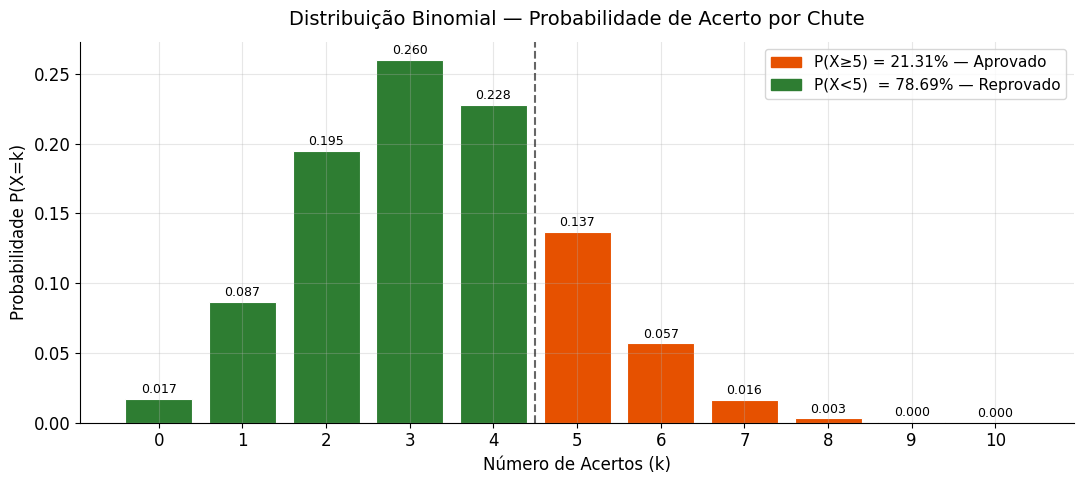

In [11]:
# ── Gráfico da distribuição binomial ──────────────────────────────────────────
x = np.arange(0, n+1)
probs = binom.pmf(x, n, p)

cores = [LARANJA if xi >= k else VERDE for xi in x]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(x, probs, color=cores, edgecolor='white', linewidth=0.8)

# Anotações em cima de cada barra
for xi, pi in zip(x, probs):
    ax.text(xi, pi + 0.002, f'{pi:.3f}', ha='center', va='bottom', fontsize=9)

ax.axvline(k - 0.5, color='black', linestyle='--', alpha=0.6, label='Nota de corte (5)')
patch1 = mpatches.Patch(color=LARANJA, label=f'P(X≥5) = {prob_passar*100:.2f}% — Aprovado')
patch2 = mpatches.Patch(color=VERDE,   label=f'P(X<5)  = {(1-prob_passar)*100:.2f}% — Reprovado')
ax.legend(handles=[patch1, patch2], fontsize=11)
ax.set_title('Distribuição Binomial — Probabilidade de Acerto por Chute', fontsize=14, pad=12)
ax.set_xlabel('Número de Acertos (k)')
ax.set_ylabel('Probabilidade P(X=k)')
ax.set_xticks(x)
plt.tight_layout()
plt.show()

In [12]:
# ── Bônus: Exemplo Gincana ─────────────────────────────────────────────────────
# 60% feminino, equipes de 12 integrantes, 30 equipes
# Quantas equipes terão exatamente 8 mulheres?
n_g, k_g, p_g = 12, 8, 0.60
total_equipes = 30
prob_8mulheres = binom.pmf(k_g, n_g, p_g)
equipes_esperadas = prob_8mulheres * total_equipes

print('── Gincana ─────────────────────────────────────')
print(f'P(exatamente 8 mulheres em 12) = {prob_8mulheres:.4f}')
print(f'Equipes esperadas com 8 mulheres: {equipes_esperadas:.1f} de 30')

── Gincana ─────────────────────────────────────
P(exatamente 8 mulheres em 12) = 0.2128
Equipes esperadas com 8 mulheres: 6.4 de 30


---
### 2.2 Distribuição de Poisson

#### 📌 Problema — Delivery
> Um restaurante recebe em média **20 pedidos por hora**.  
> Qual a chance de receber **exatamente 15 pedidos** em uma hora?

In [13]:
# ── Parâmetros ────────────────────────────────────────────────────────────────
mu = 20   # média de pedidos por hora
k_p = 15  # número de ocorrências desejado

# Solução manual com a fórmula de Poisson
prob_15_manual = (math.e**(-mu) * mu**k_p) / math.factorial(k_p)

# Solução com scipy
prob_15_scipy = poisson.pmf(k_p, mu)

print('=' * 50)
print(f'  Distribuição de Poisson  (μ = {mu})')
print('=' * 50)
print(f'  Desvio padrão σ = √μ     = {mu**0.5:.4f}')
print(f'  P(X=15) [manual]         = {prob_15_manual:.6f}')
print(f'  P(X=15) [scipy]          = {prob_15_scipy:.6f}')
print(f'\n  Probabilidade: {prob_15_scipy*100:.4f}%')

  Distribuição de Poisson  (μ = 20)
  Desvio padrão σ = √μ     = 4.4721
  P(X=15) [manual]         = 0.051649
  P(X=15) [scipy]          = 0.051649

  Probabilidade: 5.1649%


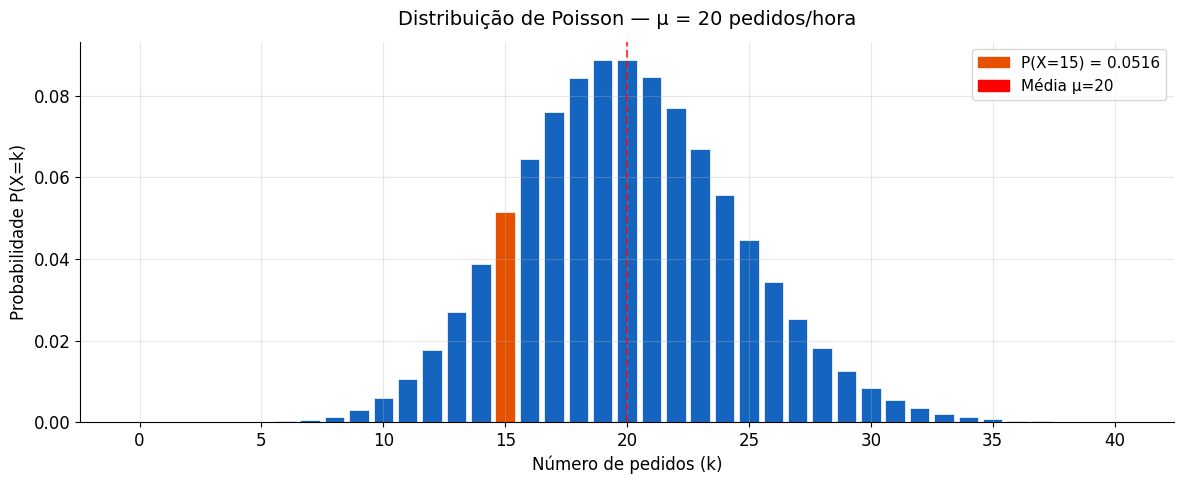

In [14]:
# ── Gráfico de Poisson ────────────────────────────────────────────────────────
x_p = np.arange(0, 41)
probs_p = poisson.pmf(x_p, mu)

fig, ax = plt.subplots(figsize=(12, 5))
cores_p = [LARANJA if xi == k_p else AZUL for xi in x_p]
ax.bar(x_p, probs_p, color=cores_p, edgecolor='white', linewidth=0.5)
ax.axvline(mu, color='red', linestyle='--', alpha=0.7, label=f'Média μ = {mu}')

patch_dest = mpatches.Patch(color=LARANJA, label=f'P(X=15) = {prob_15_scipy:.4f}')
ax.legend(handles=[patch_dest, mpatches.Patch(color='red', label=f'Média μ={mu}')], fontsize=11)
ax.set_title(f'Distribuição de Poisson — μ = {mu} pedidos/hora', fontsize=14, pad=12)
ax.set_xlabel('Número de pedidos (k)')
ax.set_ylabel('Probabilidade P(X=k)')
plt.tight_layout()
plt.show()

---
### 2.3 Distribuição Normal

#### 📌 Problema — Altura dos Moradores
> Alturas seguem distribuição normal com **μ = 1,70 m** e **σ = 0,10 m**.  
> - **A.** P(altura < 1,80 m)  
> - **B.** P(1,60 m < altura < 1,80 m)  
> - **C.** P(altura > 1,90 m)

In [15]:
# ── Parâmetros ────────────────────────────────────────────────────────────────
mu_n  = 1.70
sig_n = 0.10

def z_score(x, mu, sigma):
    return (x - mu) / sigma

# ── Problema A: P(X < 1.80) ───────────────────────────────────────────────────
z_a  = z_score(1.80, mu_n, sig_n)
p_a  = norm.cdf(z_a)

# ── Problema B: P(1.60 < X < 1.80) ──────────────────────────────────────────
z_b1 = z_score(1.60, mu_n, sig_n)
z_b2 = z_score(1.80, mu_n, sig_n)
p_b  = norm.cdf(z_b2) - norm.cdf(z_b1)

# ── Problema C: P(X > 1.90) ──────────────────────────────────────────────────
z_c  = z_score(1.90, mu_n, sig_n)
p_c  = norm.sf(z_c)   # 1 - CDF

print('=' * 55)
print(f'  Normal(μ={mu_n}, σ={sig_n})')
print('=' * 55)
print(f'  A. P(X < 1,80)          Z={z_a:+.2f} → {p_a:.4f}  ({p_a*100:.2f}%)')
print(f'  B. P(1,60 < X < 1,80)   Z=[{z_b1:+.2f}, {z_b2:+.2f}] → {p_b:.4f}  ({p_b*100:.2f}%)')
print(f'  C. P(X > 1,90)          Z={z_c:+.2f} → {p_c:.4f}  ({p_c*100:.2f}%)')

  Normal(μ=1.7, σ=0.1)
  A. P(X < 1,80)          Z=+1.00 → 0.8413  (84.13%)
  B. P(1,60 < X < 1,80)   Z=[-1.00, +1.00] → 0.6827  (68.27%)
  C. P(X > 1,90)          Z=+2.00 → 0.0228  (2.28%)


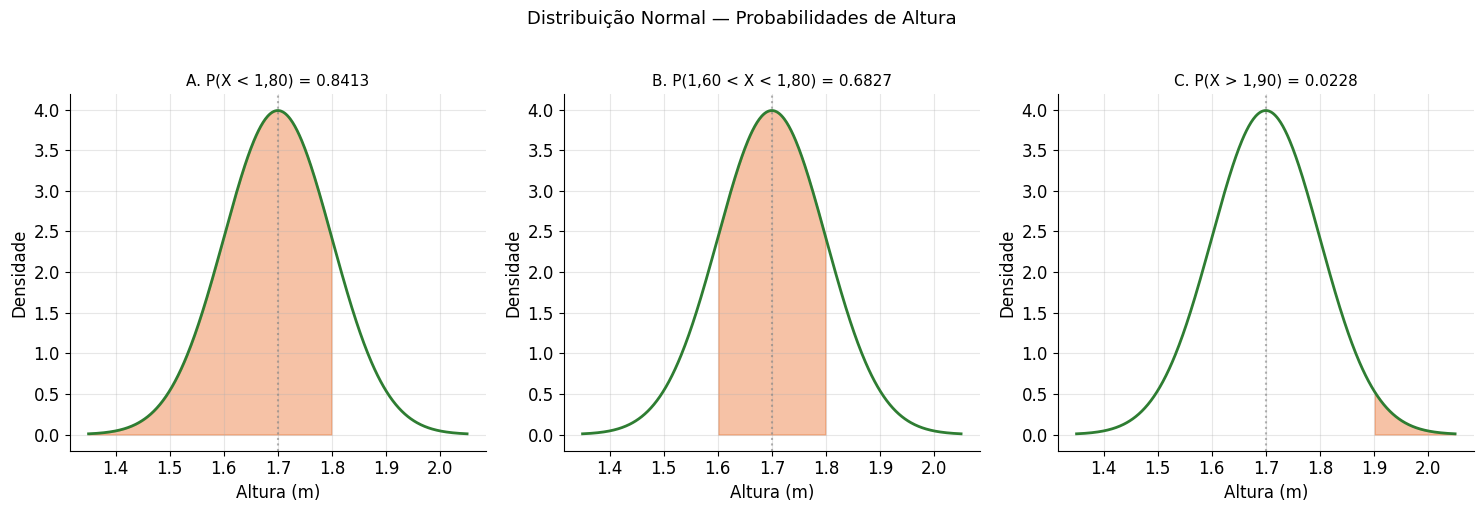

In [16]:
# ── Visualização dos três casos ───────────────────────────────────────────────
x_range = np.linspace(1.35, 2.05, 500)
y_range = norm.pdf(x_range, mu_n, sig_n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titulos = [
    f'A. P(X < 1,80) = {p_a:.4f}',
    f'B. P(1,60 < X < 1,80) = {p_b:.4f}',
    f'C. P(X > 1,90) = {p_c:.4f}'
]
limites = [(None, 1.80), (1.60, 1.80), (1.90, None)]

for ax, titulo, (li, ls) in zip(axes, titulos, limites):
    ax.plot(x_range, y_range, color=VERDE, lw=2)
    ax.axvline(mu_n, color='gray', linestyle=':', alpha=0.6)
    xi_fill = x_range[(x_range >= (li or 1.35)) & (x_range <= (ls or 2.05))]
    ax.fill_between(xi_fill, norm.pdf(xi_fill, mu_n, sig_n),
                    alpha=0.35, color=LARANJA)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Altura (m)')
    ax.set_ylabel('Densidade')

plt.suptitle('Distribuição Normal — Probabilidades de Altura', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── Tabela Normal Padronizada (Z de 0.00 a 3.90) ──────────────────────────────
tabela_z = pd.DataFrame(
    [],
    index=[f'{i/100:.2f}' for i in range(0, 400, 10)],
    columns=[f'{i/100:.2f}' for i in range(0, 10)]
)
for idx in tabela_z.index:
    for col in tabela_z.columns:
        Z = round(float(idx) + float(col), 2)
        tabela_z.loc[idx, col] = f'{norm.cdf(Z):.4f}'

tabela_z.rename_axis('Z', axis='columns', inplace=True)
print('Tabela Normal Padronizada — P(-∞ < Z < z):')
tabela_z.head(10)

Tabela Normal Padronizada — P(-∞ < Z < z):


Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.00,0.5000,0.5040,0.5080,0.5120,0.5160,0.5199,0.5239,0.5279,0.5319,0.5359
0.10,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.20,0.5793,0.5832,0.5871,0.5910,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.30,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.6480,0.6517
0.40,0.6554,0.6591,0.6628,0.6664,0.6700,0.6736,0.6772,0.6808,0.6844,0.6879
0.50,0.6915,0.6950,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.7190,0.7224
0.60,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549
0.70,0.7580,0.7611,0.7642,0.7673,0.7704,0.7734,0.7764,0.7794,0.7823,0.7852
0.80,0.7881,0.7910,0.7939,0.7967,0.7995,0.8023,0.8051,0.8078,0.8106,0.8133
0.90,0.8159,0.8186,0.8212,0.8238,0.8264,0.8289,0.8315,0.8340,0.8365,0.8389


---
## 🧪 3. Amostragem

### 3.1 Amostragem Aleatória Simples, Estratificada e por Conglomerados

In [18]:
# ── Amostragem Aleatória Simples ─────────────────────────────────────────────
SEED = 42
amostra_simples = df.sample(n=1000, random_state=SEED)
print('── Amostragem Aleatória Simples (n=1000) ─────────────────────')
print(f'Média de Renda — Amostra : R$ {amostra_simples.Renda.mean():,.2f}')
print(f'Média de Renda — Popul.  : R$ {df.Renda.mean():,.2f}')

── Amostragem Aleatória Simples (n=1000) ─────────────────────
Média de Renda — Amostra : R$ 1,972.57
Média de Renda — Popul.  : R$ 2,000.38


In [19]:
# ── Amostragem Estratificada (por Sexo, proporcional) ─────────────────────────
proporcoes = df.Sexo.value_counts(normalize=True)
n_total = 1000

amostras_estratos = []
for sexo, prop in proporcoes.items():
    n_estrato = round(prop * n_total)
    amostra_estrato = df[df.Sexo == sexo].sample(n=n_estrato, random_state=SEED)
    amostras_estratos.append(amostra_estrato)

amostra_estrat = pd.concat(amostras_estratos)
print('── Amostragem Estratificada por Sexo (n≈1000) ────────────────')
print(f'Distribuição na amostra:')
print(amostra_estrat.Sexo.value_counts().rename({0:'Masculino', 1:'Feminino'}).to_string())
print(f'\nMédia de Renda — Amostra  : R$ {amostra_estrat.Renda.mean():,.2f}')
print(f'Média de Renda — Popul.   : R$ {df.Renda.mean():,.2f}')

── Amostragem Estratificada por Sexo (n≈1000) ────────────────
Distribuição na amostra:
Sexo
Masculino    693
Feminino     307

Média de Renda — Amostra  : R$ 1,800.38
Média de Renda — Popul.   : R$ 2,000.38


In [20]:
# ── Amostragem por Conglomerados (por UF) ─────────────────────────────────────
np.random.seed(SEED)
ufs_sorteadas = np.random.choice(df.UF.unique(), size=5, replace=False)
amostra_conglo = df[df.UF.isin(ufs_sorteadas)]

print('── Amostragem por Conglomerados (5 UFs sorteadas) ─────────────')
print(f'UFs selecionadas: {sorted(ufs_sorteadas)}')
print(f'Total de registros: {len(amostra_conglo):,}')
print(f'Média de Renda — Amostra : R$ {amostra_conglo.Renda.mean():,.2f}')
print(f'Média de Renda — Popul.  : R$ {df.Renda.mean():,.2f}')

── Amostragem por Conglomerados (5 UFs sorteadas) ─────────────
UFs selecionadas: [np.int64(11), np.int64(22), np.int64(23), np.int64(27), np.int64(42)]
Total de registros: 9,285
Média de Renda — Amostra : R$ 1,607.30
Média de Renda — Popul.  : R$ 2,000.38


---
## 📐 4. Estimação — Intervalos de Confiança

#### 📌 Problema — Sacos de Arroz
> Desvio padrão populacional = 150 g  
> Amostra aleatória: n = 20 sacos, média = 5.050 g  
> Construir IC com **nível de significância de 5%**.

In [21]:
# ── Parâmetros do problema ────────────────────────────────────────────────────
x_barra = 5050   # média amostral (g)
sigma   = 150    # desvio padrão populacional (g)
n_sacos = 20     # tamanho da amostra
alpha   = 0.05   # nível de significância
confianca = 1 - alpha

# ── Obtendo z crítico ─────────────────────────────────────────────────────────
z_crit = norm.ppf(1 - alpha/2)   # bicaudal

# ── Erro padrão e erro inferencial ────────────────────────────────────────────
erro_padrao    = sigma / math.sqrt(n_sacos)
erro_inferencial = z_crit * erro_padrao

# ── Intervalo de Confiança ────────────────────────────────────────────────────
ic_inferior = x_barra - erro_inferencial
ic_superior = x_barra + erro_inferencial

print('=' * 55)
print(f'  Intervalo de Confiança para a Média')
print('=' * 55)
print(f'  Nível de confiança (1-α) = {confianca*100:.0f}%')
print(f'  Valor crítico z          = {z_crit:.4f}')
print(f'  Erro padrão σ_x̄          = {erro_padrao:.4f} g')
print(f'  Erro inferencial e       = {erro_inferencial:.4f} g')
print(f'  IC: [{ic_inferior:.2f} g ,  {ic_superior:.2f} g]')
print(f'\n  μ = {x_barra} ± {erro_inferencial:.2f} g  (com 95% de confiança)')

  Intervalo de Confiança para a Média
  Nível de confiança (1-α) = 95%
  Valor crítico z          = 1.9600
  Erro padrão σ_x̄          = 33.5410 g
  Erro inferencial e       = 65.7392 g
  IC: [4984.26 g ,  5115.74 g]

  μ = 5050 ± 65.74 g  (com 95% de confiança)


In [22]:
# ── Tabela de referência dos z mais usados ────────────────────────────────────
ref = pd.DataFrame({
    'Nível de Confiança': ['90%', '95%', '99%'],
    'α': [0.10, 0.05, 0.01],
    'Área sob a curva': [0.95, 0.975, 0.995],
    'z crítico': [norm.ppf(0.95), norm.ppf(0.975), norm.ppf(0.995)]
})
ref['z crítico'] = ref['z crítico'].round(4)
print('Valores de z para os níveis de confiança mais utilizados:')
ref

Valores de z para os níveis de confiança mais utilizados:


,Nível de Confiança,α,Área sob a curva,z crítico
0,90%,0.10,0.950,1.6449
1,95%,0.05,0.975,1.9600
2,99%,0.01,0.995,2.5758


---
## 📏 5. Cálculo do Tamanho da Amostra

### 5.1 População Infinita
#### 📌 Problema — Rendimento Médio
> Erro máximo: R$ 100,00 | σ = R$ 3.323,39 | Confiança: 95%

In [23]:
# ── Fórmula: n = (z * sigma / e)^2 ───────────────────────────────────────────
sigma_r = 3323.39
e_r     = 100
z_95    = norm.ppf(0.975)

n_infinita = math.ceil((z_95 * sigma_r / e_r) ** 2)
print(f'── Tamanho da Amostra (Pop. Infinita) ─────────────────────────')
print(f'σ = R$ {sigma_r:,.2f}  |  e = R$ {e_r:.2f}  |  z = {z_95:.4f}')
print(f'n = ⌈(z × σ / e)²⌉ = ⌈({z_95:.4f} × {sigma_r} / {e_r})²⌉ = {n_infinita}')

── Tamanho da Amostra (Pop. Infinita) ─────────────────────────
σ = R$ 3,323.39  |  e = R$ 100.00  |  z = 1.9600
n = ⌈(z × σ / e)²⌉ = ⌈(1.9600 × 3323.39 / 100)²⌉ = 4243


### 5.2 População Finita
#### 📌 Problema — Indústria de Refrigerantes
> N = 10.000 latas | s = 12 ml | e = 5 ml | Confiança: 95%

In [24]:
# ── Fórmula: n = (z² s² N) / (z² s² + e²(N-1)) ──────────────────────────────
N_pop = 10_000
s_ml  = 12
e_ml  = 5

numerador   = z_95**2 * s_ml**2 * N_pop
denominador = z_95**2 * s_ml**2 + e_ml**2 * (N_pop - 1)
n_finita    = math.ceil(numerador / denominador)

print(f'── Tamanho da Amostra (Pop. Finita) ────────────────────────────')
print(f'N = {N_pop:,}  |  s = {s_ml} ml  |  e = {e_ml} ml  |  z = {z_95:.4f}')
print(f'n = ⌈(z²s²N) / (z²s² + e²(N-1))⌉ = {n_finita}')

── Tamanho da Amostra (Pop. Finita) ────────────────────────────
N = 10,000  |  s = 12 ml  |  e = 5 ml  |  z = 1.9600
n = ⌈(z²s²N) / (z²s² + e²(N-1))⌉ = 23


---
## 🏁 6. Fixando o Conteúdo — Estudo Completo de Rendimento

#### 📌 Problema Final
> **Chefes de domicílio com renda até R$ 5.000,00**  
> - Erro máximo: R$ 10,00 | σ = R$ 1.082,79 | μ = R$ 1.426,54 | Confiança: 95%  
> - Calcular: (1) tamanho da amostra → (2) IC para a média → (3) prova gráfica

In [25]:
# ── Construindo o dataset conforme o problema ─────────────────────────────────
mu_pop    = 1426.54
sigma_pop = 1082.79
e_final   = 10

# Dataset simulado representando a população
np.random.seed(SEED)
populacao = pd.DataFrame({'Renda': np.random.normal(mu_pop, sigma_pop, 100_000)})
populacao = populacao[populacao.Renda.between(0, 5000)]
print(f'Dataset: {len(populacao):,} registros | μ≈R${populacao.Renda.mean():,.2f} | σ≈R${populacao.Renda.std():,.2f}')

Dataset: 90,575 registros | μ≈R$1,625.95 | σ≈R$917.98


In [26]:
# ── 1. Calculando n ───────────────────────────────────────────────────────────
n_final = math.ceil((z_95 * sigma_pop / e_final) ** 2)
print(f'1️⃣  Tamanho da amostra necessário: n = {n_final:,}')

1️⃣  Tamanho da amostra necessário: n = 45,039


In [27]:
# ── 2. Calculando o IC ────────────────────────────────────────────────────────
amostra_final = populacao.sample(n=n_final, random_state=SEED)
x_barra_f     = amostra_final.Renda.mean()
e_ic          = z_95 * sigma_pop / math.sqrt(n_final)
ic_inf_f      = x_barra_f - e_ic
ic_sup_f      = x_barra_f + e_ic

print(f'2️⃣  Média amostral         : R$ {x_barra_f:,.2f}')
print(f'   Erro inferencial (e)  : R$ {e_ic:.4f}')
print(f'   IC (95%): [R$ {ic_inf_f:,.2f}  ,  R$ {ic_sup_f:,.2f}]')
print(f'\n   μ real = R$ {mu_pop:,.2f} → {'✅ Dentro do IC' if ic_inf_f <= mu_pop <= ic_sup_f else '❌ Fora do IC'}')

2️⃣  Média amostral         : R$ 1,624.82
   Erro inferencial (e)  : R$ 10.0000
   IC (95%): [R$ 1,614.82  ,  R$ 1,634.82]

   μ real = R$ 1,426.54 → ❌ Fora do IC


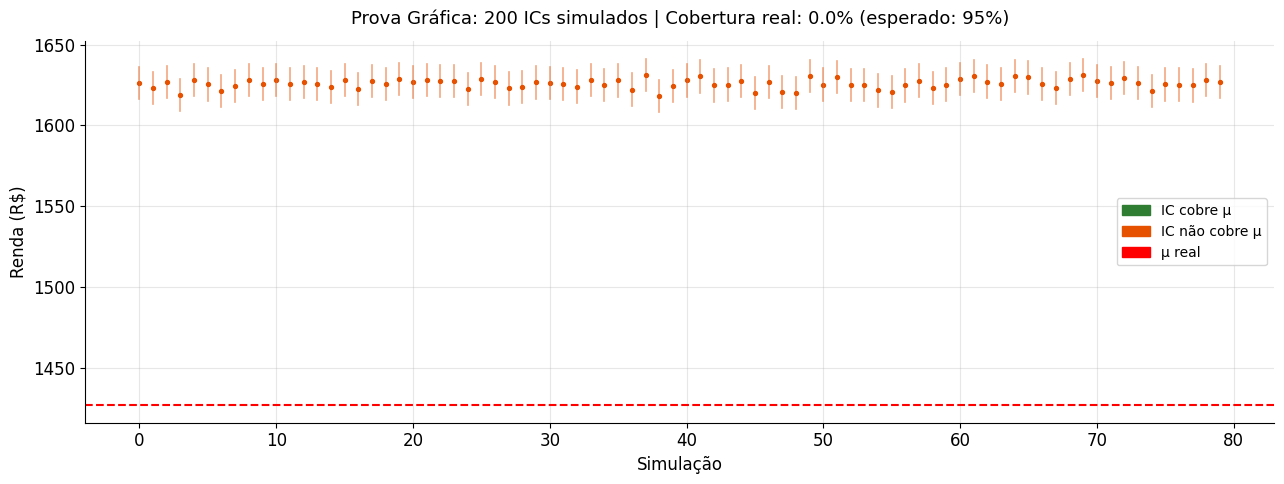

✅ Taxa de cobertura observada: 0.0%  (nível de confiança teórico: 95%)


In [28]:
# ── 3. Prova gráfica ──────────────────────────────────────────────────────────
# Simulando múltiplas amostras para mostrar a cobertura do IC
n_simulacoes = 200
medias_simuladas = []
cobertos = []

for i in range(n_simulacoes):
    amostra_sim = populacao.sample(n=n_final, random_state=i)
    media_sim   = amostra_sim.Renda.mean()
    ic_i = z_95 * sigma_pop / math.sqrt(n_final)
    medias_simuladas.append(media_sim)
    cobertos.append(abs(media_sim - mu_pop) <= ic_i)

taxa_cobertura = sum(cobertos) / n_simulacoes

# Gráfico
fig, ax = plt.subplots(figsize=(13, 5))
for i, (media, coberto) in enumerate(zip(medias_simuladas[:80], cobertos[:80])):
    cor = VERDE if coberto else LARANJA
    ax.plot([i, i], [media - e_ic, media + e_ic], color=cor, alpha=0.5, lw=1.2)
    ax.scatter(i, media, s=8, color=cor)

ax.axhline(mu_pop, color='red', linestyle='--', lw=1.5, label=f'μ = R$ {mu_pop:,.2f}')
patch_ok  = mpatches.Patch(color=VERDE,   label=f'IC cobre μ')
patch_err = mpatches.Patch(color=LARANJA, label=f'IC não cobre μ')
ax.legend(handles=[patch_ok, patch_err, mpatches.Patch(color='red', label=f'μ real')], fontsize=10)
ax.set_title(f'Prova Gráfica: {n_simulacoes} ICs simulados | Cobertura real: {taxa_cobertura*100:.1f}% (esperado: 95%)',
             fontsize=13, pad=12)
ax.set_xlabel('Simulação')
ax.set_ylabel('Renda (R$)')
plt.tight_layout()
plt.show()
print(f'✅ Taxa de cobertura observada: {taxa_cobertura*100:.1f}%  (nível de confiança teórico: 95%)')

---

## ✅ Resumo Final

| Conteúdo | Conceito-chave | Ferramentas |
|---|---|---|
| **Binomial** | Eventos de sucesso/fracasso em $n$ tentativas | `scipy.stats.binom` |
| **Poisson** | Contagem de eventos em intervalo de tempo/espaço | `scipy.stats.poisson` |
| **Normal** | Distribuição contínua simétrica — área = probabilidade | `scipy.stats.norm` |
| **Amostragem** | Simples, Estratificada, Conglomerados | `pandas.DataFrame.sample` |
| **IC para a Média** | $\bar{x} \pm z\,\sigma/\sqrt{n}$ | `norm.ppf` + fórmula |
| **Tamanho Amostral** | $n = (z\,\sigma/e)^2$ | `math.ceil` |

---
*Notebook produzido com base na PNAD 2015 (IBGE). Fins educacionais.*